In [33]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib

from scaler import train_scaler,save_scaler

print("Import Successfully........:")

Import Successfully........:


In [2]:
df = pd.read_csv("housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
# mainroad
# guestroom
# basement
# hotwaterheating
# airconditioning
# prefarea
# furnishingstatus
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [6]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [19]:
df['price_per_sqft'] = df['price'] / df['area']
df['bed_bath_ratio'] = df['bedrooms'] / df['bathrooms']

In [20]:
X=df.drop('price',axis=1)
y=df['price']

In [35]:
#use scaler module
#scaler, X_train_scaled = train_scaler(X_train)
#X_train_scaled = scaler.transform(X_test)

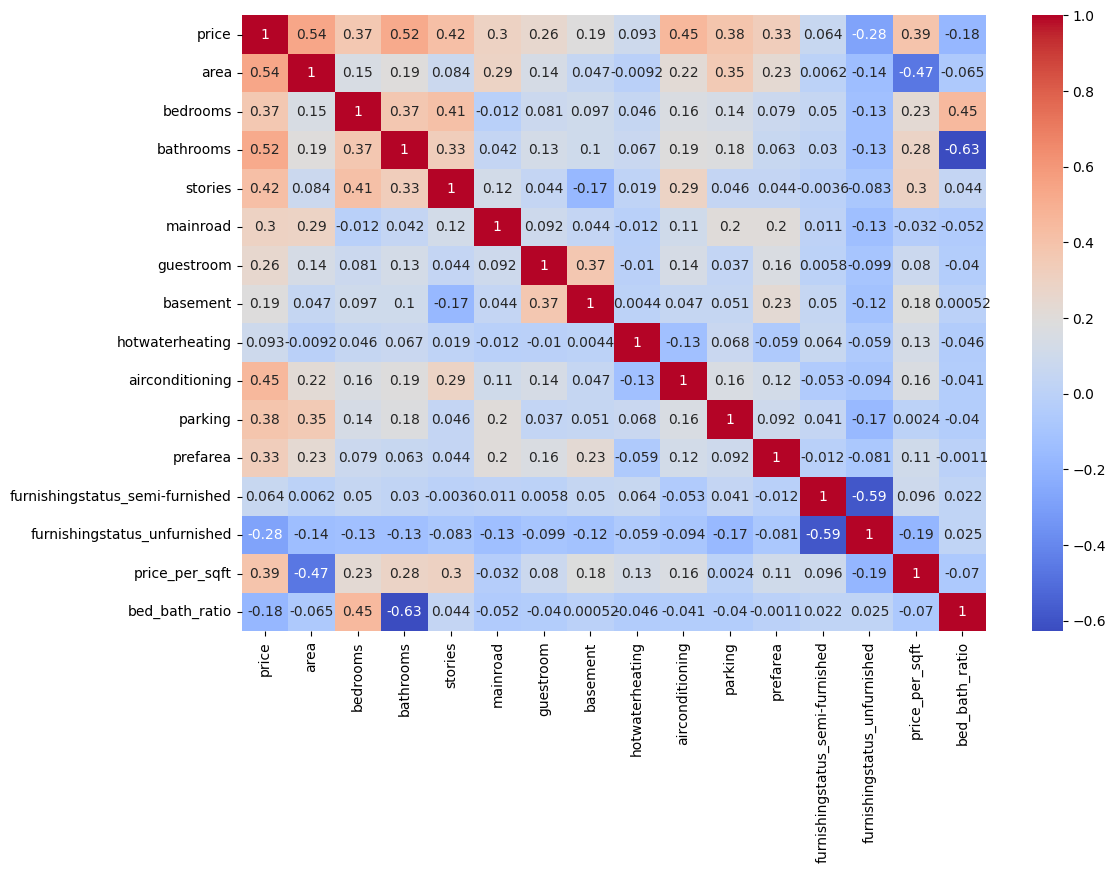

In [21]:
# df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [22]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,random_state=50,test_size=0.2
)

In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred = model.predict(X_test)
y_pred

array([ 4177341.12829877,  7966084.41413011,  3355141.72266045,
        3124882.78203518,  1409851.51277589,  6877719.15170713,
        5893755.39996368,  4180413.88745983,  4300563.84741858,
        3960031.11975162,  3324541.13460947,  3740395.54728045,
        3791767.88553648,  5020947.65004524,  6569068.91507088,
        4447572.79761667,  4835524.73735378,  3268291.91856763,
        5635845.96201783,  8583544.0701519 ,  5298393.06332913,
        5360991.40404416,  4364096.22706943,  2312925.52001738,
        5420244.01093373,  1463685.42706366,  3967942.85238662,
        3133185.67572745,  4765195.71558021,  2330960.53292937,
        3941231.33911849,  4901067.97484841,  3534230.65446023,
        4075860.83418224,  6123428.34539691,  3061815.87564209,
        2469794.89171953,  6377112.70150259,  4699240.36367202,
        4560902.55391494,  3417600.63040343,  1502009.89815199,
        3094525.65648328,  7509190.65414911,  5097339.74876442,
        7072272.70789596,  3325049.72352

In [32]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8416970434794819

In [38]:
joblib.dump(model,'housing.pkl')
save_scaler(scaler)
print("Model and scaler saved Successfully")

NameError: name 'save_scaler' is not defined